# Training GCN model

## Import Lib and define paths

In [37]:
# === Path Variables ===# Healthy

import os  # For handling file paths and directories
import pandas as pd  # For working with tabular data using DataFrames
import matplotlib.pyplot as plt  # For generating plots
import seaborn as sns  # For enhanced visualizations of heatmaps
import zipfile  # For reading compressed files without extracting them
import re  # For extracting numerical IDs using regular expressions

import torch
import random
import numpy as np

import os
import pandas as pd
import numpy as np

import networkx as nx  # For graph-level metrics


BASE_DIR = "../../../input_columns_1mm/input_columns"
QSM_DIR = "../../../QSM"
SUBJECT_IDS_CSV = "../../age_prediction_on_columns_analyses/subject_ids.csv"
AGE_CSV = "../../age_prediction_on_columns_analyses/ages.csv"
THICKNESS_DIR = '../../../thickness_in_region'
subject_df = pd.read_csv(SUBJECT_IDS_CSV, header=None)
age_df = pd.read_csv(AGE_CSV, header=None)
metadata_path = "../../../AD_DECODE_data3.xlsx"
df_metadata = pd.read_excel(metadata_path)


In [38]:
# === Set seed for reproducibility ===
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

#Load columns

# Base directory where subject folders (e.g., S00775_columns_1mm) are stored


In [39]:
# List of hemispheres
HEMIS = ["lh", "rh"]


In [40]:
# List of cortical regions (based on the parcellation used)
REGION_NAMES = ['bankssts',
'caudalanteriorcingulate',
'caudalmiddlefrontal',
'cuneus',
'entorhinal',
'fusiform',
'inferiorparietal',
'inferiortemporal',
'isthmuscingulate',
'lateraloccipital',
'lateralorbitofrontal',
'lingual',
'medialorbitofrontal',
'middletemporal',
'parahippocampal',
'paracentral',
'parsopercularis',
'parsorbitalis',
'parstriangularis',
'pericalcarine',
'postcentral',
'posteriorcingulate',
'precentral',
'precuneus',
'rostralanteriorcingulate',
'rostralmiddlefrontal',
'superiorfrontal',
'superiorparietal',
'superiortemporal',
'supramarginal',
'frontalpole',
'temporalpole',
'transversetemporal',
'insula'
]


## Read data

In [41]:
############################## METADATA ##############################

print("ADDECODE METADATA\n")

ADDECODE METADATA



In [42]:
# Zero-pad subject IDs to 5-digit strings
subject_ids = subject_df[0].astype(str).apply(lambda x: x.zfill(5)).tolist()

In [43]:
# Standardize MRI_Exam IDs
df_metadata["MRI_Exam_fixed"] = (
    df_metadata["MRI_Exam"]
    .fillna(0)
    .astype(int)
    .astype(str)
    .str.zfill(5)
)


In [44]:
# Drop fully empty rows and rows missing MRI_Exam
df_metadata_cleaned = df_metadata.dropna(how="all")
df_metadata_cleaned = df_metadata_cleaned.dropna(subset=["MRI_Exam"])


In [45]:
# === Filter metadata to match only included subject IDs ===
df_matched = df_metadata_cleaned[df_metadata_cleaned["MRI_Exam_fixed"].isin(subject_ids)].copy()


In [46]:
# === Only keep valid IDs for reordering to avoid KeyError ===
valid_ids = [sid for sid in subject_ids if sid in df_matched["MRI_Exam_fixed"].values]


In [47]:
# === Reorder safely ===
df_matched = df_matched.set_index("MRI_Exam_fixed").loc[valid_ids].reset_index()


In [48]:
# === Clean 'Risk' column: treat NaNs and empty strings as 'NoRisk' ===
df_matched["Risk"] = (
    df_matched["Risk"]
    .fillna("NoRisk")                              # Replace NaNs
    .replace(r'^\s*$', "NoRisk", regex=True)       # Replace empty strings or whitespace
    .str.strip()                                   # Remove leading/trailing spaces
)


In [49]:
# === Filter only healthy or familial risk subjects ===
df_matched_filtered = df_matched[df_matched["Risk"].isin(["NoRisk", "Familial"])].copy()


In [50]:
# === Print summary ===
print("Remaining risk group distribution:")
print(df_matched_filtered["Risk"].value_counts())
print(f"\nSubjects before filtering: {len(df_matched)}")
print(f"Subjects after filtering:  {len(df_matched_filtered)}")


Remaining risk group distribution:
Risk
Familial    48
NoRisk      19
Name: count, dtype: int64

Subjects before filtering: 72
Subjects after filtering:  67


In [51]:
# Build age_dict from the healthy metadata dataframe
age_dict = dict(zip(df_matched_filtered["MRI_Exam_fixed"], df_matched_filtered["age"]))


In [52]:
# === Extract filtered subject IDs (already cleaned and filtered to NoRisk / Familial) ===
subject_ids = df_matched_filtered["MRI_Exam_fixed"].tolist()


In [53]:
# === Initialize final dictionary: subject_id -> region -> matrix ===
column_data_md = {}
column_data_QSM = {}
column_data_thickness = {}


In [54]:
# === Loop through filtered subjects ===
for subj_id in subject_ids:
    subj_dict = {}
    subj_dir = os.path.join(BASE_DIR, f"S{subj_id}_columns_1mm")  # Path to subject's folder
    subj_dict_thickness = {}
    subj_dir_to_thickness = os.path.join(THICKNESS_DIR, f"S{subj_id}")  # Path to subject's thickness folder
    subj_dict_QSM = {}
    subj_dir_to_QSM = os.path.join(QSM_DIR, f"S{subj_id}", "QSM")  # Path to subject's QSM folder

    for hemi in HEMIS:
        for region in REGION_NAMES:
            region_key = f"{hemi}_{region}"
            filename = f"S{subj_id}_{region_key}_md.csv"
            thickness_filename = f"S{subj_id}{region_key}_thickness.csv"
            QSM_filename = f"S{subj_id}_{region_key}_QSM.csv"
            # Construct full file path
            filepath = os.path.join(subj_dir, filename)
            thickness_filepath = os.path.join(subj_dir_to_thickness, thickness_filename)
            QSM_filepath = os.path.join(subj_dir_to_QSM, QSM_filename)

            if not os.path.exists(filepath):
                # print(f"[WARNING] Missing: {filepath}")
                continue
            if not os.path.exists(thickness_filepath):
                # print(f"[WARNING] Missing thickness file: {thickness_filepath}")
                continue

            if not os.path.exists(QSM_filepath):
                # print(f"[WARNING] Missing QSM file: {QSM_filepath}")
                continue

            # Load the thickness CSV matrix and get the mean thickness value
            thickness_mat = pd.read_csv(thickness_filepath, header=None).values.astype(np.float32)
            if thickness_mat.size == 0:
                print(f"[WARNING] Empty thickness matrix for {thickness_filepath}")
                continue
            # Calculate mean thickness for the region
            mean_thickness = np.mean(thickness_mat)
            subj_dict_thickness[region_key] = mean_thickness

            # Load MD CSV matrix as numpy array (float32)
            mat = pd.read_csv(filepath, header=None).values.astype(np.float32)
            # Add mean thickness as an additional attribute to the matrix
            if mat.size == 0:
                print(f"[WARNING] Empty matrix for {filepath}")
                continue
            subj_dict[region_key] = mat

            # Load QSM CSV matrix as numpy array (float32)
            QSM_mat = pd.read_csv(QSM_filepath, header=None).values.astype(np.float32)
            if QSM_mat.size == 0:
                print(f"[WARNING] Empty QSM matrix for {QSM_filepath}")
                continue
            subj_dict_QSM[region_key] = QSM_mat



    if len(subj_dict) > 0:
        column_data_md[subj_id] = subj_dict
    else:
        print(f"[INFO] Skipping subject {subj_id} (no valid regions found)")
    
    if len(subj_dict_thickness) > 0:
        column_data_thickness[subj_id] = subj_dict_thickness
    else:
        print(f"[INFO] Skipping subject {subj_id} (no valid regions found)")
    
    if len(subj_dict_QSM) > 0:
        column_data_QSM[subj_id] = subj_dict_QSM
    else:
        print(f"[INFO] Skipping subject {subj_id} (no valid regions found)")



[INFO] Skipping subject 02231 (no valid regions found)
[INFO] Skipping subject 02231 (no valid regions found)
[INFO] Skipping subject 02231 (no valid regions found)
[INFO] Skipping subject 03350 (no valid regions found)
[INFO] Skipping subject 03350 (no valid regions found)
[INFO] Skipping subject 03350 (no valid regions found)
[INFO] Skipping subject 03866 (no valid regions found)
[INFO] Skipping subject 03866 (no valid regions found)
[INFO] Skipping subject 03866 (no valid regions found)
[INFO] Skipping subject 01412 (no valid regions found)
[INFO] Skipping subject 01412 (no valid regions found)
[INFO] Skipping subject 01412 (no valid regions found)
[INFO] Skipping subject 01619 (no valid regions found)
[INFO] Skipping subject 01619 (no valid regions found)
[INFO] Skipping subject 01619 (no valid regions found)


In [55]:
# === OPTIONAL: Print region shapes for each subject ===
# for subj_id, regions in column_data.items():
#     print(f"\nSubject {subj_id}:")
#     for region_name, matrix in regions.items():
#         print(f"  {region_name} → {matrix.shape}")


## Construct Graphs

In [56]:
# CONSTRUCT GRAPHS 

import os
import numpy as np
import pandas as pd
import torch
from torch_geometric.data import Data
from sklearn.neighbors import NearestNeighbors


In [57]:
# === STEP 1: Build edge_index from K-Nearest Neighbors ===

def build_knn_edge_index(x_np, k=10):
    """
    Builds the edge_index for a graph using KNN based on node features.

    Args:
        x_np (np.ndarray): shape [n_nodes, n_features]
        k (int): number of neighbors per node

    Returns:
        edge_index (torch.LongTensor): shape [2, num_edges]
    """
    knn = NearestNeighbors(n_neighbors=k, metric="euclidean")
    knn.fit(x_np)
    knn_graph = knn.kneighbors_graph(x_np).tocoo()

    edge_index = torch.tensor(
        np.vstack((knn_graph.row, knn_graph.col)),
        dtype=torch.long
    )
    return edge_index


In [58]:
# === STEP 2: Build PyG graph from a single subject ===

def build_graph_from_subject(subj_id, column_data, age_dict, k=10):
    """
    Converts one subject's cortical column data into a PyTorch Geometric graph.

    Args:
        subj_id (str): subject ID
        column_data (dict): {subject_id → {region_name → matrix}}
        age_dict (dict): {subject_id → age}
        k (int): number of KNN neighbors

    Returns:
        Data: PyTorch Geometric graph with x, edge_index, y
    """

    # Get all regions from this subject and stack all columns
    subj_regions = column_data[subj_id]
    x_np = np.vstack(list(subj_regions.values()))  # shape [n_columns_total, 22]


    # Convert features to tensor
    x = torch.tensor(x_np, dtype=torch.float32)


    # Build edge_index using KNN over node features
    edge_index = build_knn_edge_index(x_np, k=k)


    # Get subject's age and convert to tensor
    y = torch.tensor([age_dict[subj_id]], dtype=torch.float32)


    # Create PyG Data object
    data = Data(x=x, edge_index=edge_index, y=y)
    data.subject_id = subj_id  # optional: store ID for reference
    return data


In [59]:
# === STEP 3: Loop through all subjects and build their graphs ===

# Build MD graphs for each subject
graph_data_list_md = []
for subj_id in column_data_md:
    if subj_id in age_dict:
        graph = build_graph_from_subject(subj_id, column_data_md, age_dict, k=10)
        graph_data_list_md.append(graph)
        print(f" Built MD graph for subject {subj_id} with {graph.num_nodes} nodes")
    else:
        print(f"[WARNING] No age found for subject {subj_id}")

# Build QSM graphs for each subject
graph_data_list_QSM = []
for subj_id in column_data_QSM:
    if subj_id in age_dict:
        graph = build_graph_from_subject(subj_id, column_data_QSM, age_dict, k=10)
        graph_data_list_QSM.append(graph)
        print(f" Built QSM graph for subject {subj_id} with {graph.num_nodes} nodes")
    else:
        print(f"[WARNING] No age found for subject {subj_id}")

# Create lookup dictionary from subject IDs to their graphs
md_dict = {data.subject_id: data for data in graph_data_list_md}
qsm_dict = {data.subject_id: data for data in graph_data_list_QSM}

# Build aligned list of MD, QSM graphs and thickness
aligned_graph_list =[(md_dict[subj_id], qsm_dict[subj_id], column_data_thickness[subj_id]) 
                     for subj_id in md_dict.keys() if subj_id in qsm_dict and subj_id in column_data_thickness]

#collate function for DataLoader
def collate_fn_aligend(batch):
    """
    Custom collate function to handle aligned MD, QSM, and thickness data.
    """
    # Unzip the batch into three lists
    md_data, qsm_data, thickness_data = zip(*batch)

    # Stack MD and QSM data
    md_batch = Data.from_data_list(md_data)
    qsm_batch = Data.from_data_list(qsm_data)

    # Convert thickness data to tensor
    thickness_tensor = torch.tensor([thickness for thickness in thickness_data], dtype=torch.float32)

    return md_batch, qsm_batch, thickness_tensor


 Built MD graph for subject 02110 with 68 nodes
 Built MD graph for subject 02363 with 68 nodes
 Built MD graph for subject 02373 with 68 nodes
 Built MD graph for subject 02386 with 68 nodes
 Built MD graph for subject 02390 with 68 nodes
 Built MD graph for subject 02402 with 68 nodes
 Built MD graph for subject 02410 with 68 nodes
 Built MD graph for subject 02421 with 68 nodes
 Built MD graph for subject 01912 with 68 nodes
 Built MD graph for subject 02424 with 68 nodes
 Built MD graph for subject 02446 with 68 nodes
 Built MD graph for subject 02451 with 68 nodes
 Built MD graph for subject 02485 with 68 nodes
 Built MD graph for subject 02473 with 68 nodes
 Built MD graph for subject 02491 with 68 nodes
 Built MD graph for subject 02506 with 68 nodes
 Built MD graph for subject 02524 with 68 nodes
 Built MD graph for subject 02535 with 68 nodes
 Built MD graph for subject 02654 with 68 nodes
 Built MD graph for subject 02666 with 68 nodes
 Built MD graph for subject 02690 with 6

ValueError: Input X contains NaN.
NearestNeighbors does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

## Visualize graph_md ad graph_QSM


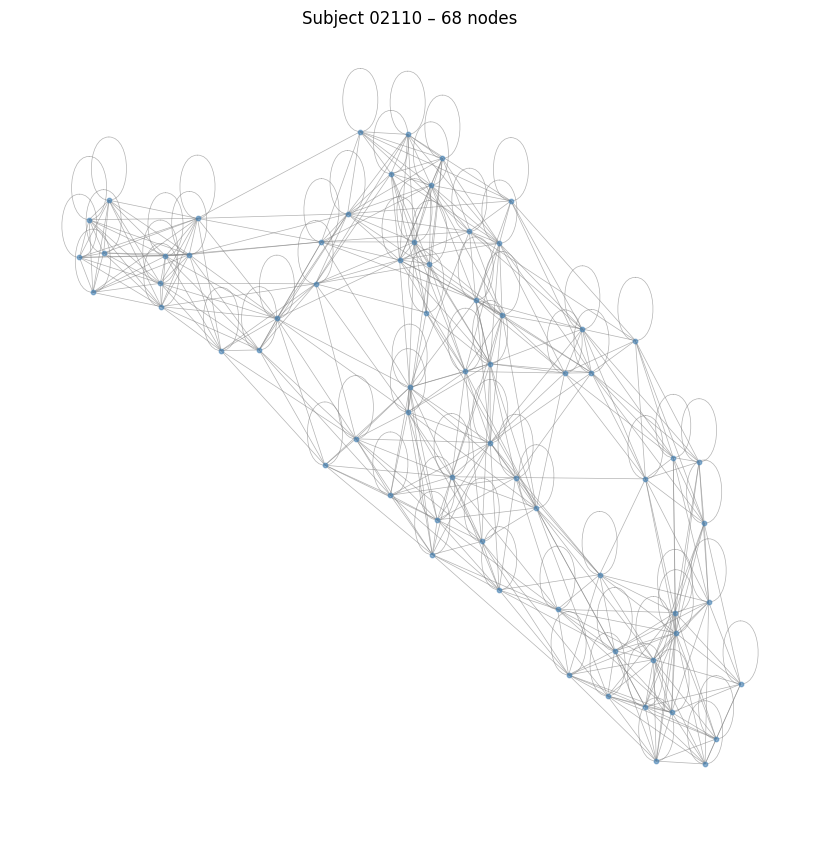

In [ ]:

import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx


# === Pick the first subject's graph_md ===
graph_md = graph_data_list_md[0]

# === Convert PyG graph_md to NetworkX for visualization ===
G_md = to_networkx(graph_md, to_undirected=True)

# === Optional: layout (slower for large graphs) ===
pos_md = nx.spring_layout(G_md, seed=42)  # force-directed layout

graph_QSM = graph_data_list_QSM[0]
G_QSM = to_networkx(graph_QSM, to_undirected=True)
pos_QSM = nx.spring_layout(G_QSM, seed=42)  # force-directed layout

# === Plot the MD and QSM graphs side by side ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
# === MD Graph ===
nx.draw(G_md, pos=pos_md, with_labels=True, node_size=50, font_size=8, ax=ax1)
ax1.set_title("MD Graph")
# === QSM Graph ===
nx.draw(G_QSM, pos=pos_QSM, with_labels=True, node_size=50, font_size=8, ax=ax2)
ax2.set_title("QSM Graph")
plt.tight_layout()
plt.show()


In [ ]:
#####################  DEVICE CONFIGURATION  #######################

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Define Model GCN

In [ ]:
#DEFINE MODEL GCNs
import torch
import torch.nn.functional as F
import torch.nn as nn
from torch_geometric.nn import GCNConv, global_mean_pool, batch_Norm

class BrainAgeGNN(torch.nn.Module):
    def __init__(self, input_dim=21):  # ← set to 22 features per node
        super(BrainAgeGNN, self).__init__()

        # GCN layers with batch normalization for MD
        self.md_conv1 = GCNConv(input_dim, 64)
        self.md_bn1 = batch_Norm(64)

        self.md_conv2 = GCNConv(64, 128)
        self.md_bn2 = batch_Norm(128)

        self.md_conv3 = GCNConv(128, 128)
        self.md_bn3 = batch_Norm(128)

        # GCN layers with batch normalization for QSM
        self.qsm_conv1 = GCNConv(input_dim, 64)
        self.qsm_bn1 = batch_Norm(64)

        self.qsm_conv2 = GCNConv(64, 128)
        self.qsm_bn2 = batch_Norm(128)

        self.qsm_conv3 = GCNConv(128, 128)
        self.qsm_bn3 = batch_Norm(128)

        self.dropout = torch.nn.Dropout(p=0.5)

        # Final fully connected layer
        self.fc = nn.Sequential(
            nn.Linear(128 + 128 + 1, 128), # 128 for MD, 128 for QSM, 1 for thickness
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(128, 64),  # Intermediate layer
            nn.ReLU(),
            nn.Linear(64, 1)  # Output layer for regression
        )
        
    def forward(self, data_md, data_qsm, data_thickness=None):
        # Forward pass for MD data
        x_md, edge_index_md, batch_md = data_md.x_md, data_md.edge_index_md, data_md.batch_md

        x_md = F.relu(self.md_bn1(self.md_conv1(x_md, edge_index_md)))
        x_md = F.relu(self.md_bn2(self.md_conv2(x_md, edge_index_md)))
        x_md_residual = x_md
        x_md = F.relu(self.md_bn3(self.md_conv3(x_md, edge_index_md)))
        x_md = x_md + x_md_residual

        x_md = global_mean_pool(x_md, batch_md)
        x_md = self.dropout(x_md)

        # Forward pass for QSM data
        x_qsm, edge_index_qsm, batch_qsm = data_qsm.x_qsm, data_qsm.edge_index_qsm, data_qsm.batch_qsm

        x_qsm = F.relu(self.qsm_bn1(self.qsm_conv1(x_qsm, edge_index_qsm)))
        x_qsm = F.relu(self.qsm_bn2(self.qsm_conv2(x_qsm, edge_index_qsm)))
        x_qsm_residual = x_qsm
        x_qsm = F.relu(self.qsm_bn3(self.qsm_conv3(x_qsm, edge_index_qsm)))
        x_qsm = x_qsm + x_qsm_residual

        x_qsm = global_mean_pool(x_qsm, batch_qsm)
        x_qsm = self.dropout(x_qsm)

        x = []

        # Concatenate MD, QSM and thickness features
        if data_thickness is not None:
            thickness = data_thickness.view(-1, 1)
            x = torch.cat((x_md, x_qsm, thickness), dim=1)
        else:
            x = torch.cat((x_md, x_qsm), dim=1)
        
        # Final fully connected layer
        x = self.fc(x)

        return x


In [ ]:
  #train and eval funcions  
    
from torch.optim import Adam
from torch_geometric.loader import DataLoader  # Usamos el DataLoader de torch_geometric

def train(model, train_loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for data_md, data_QSM, data_thickness in train_loader:
        data_md = data_md.to(device)  # GPU
        data_QSM = data_QSM.to(device)
        data_thickness = data_thickness.to(device) if data_thickness is not None else None
        optimizer.zero_grad()
        output = model(data_md, data_QSM, data_thickness).view(-1)
        loss = criterion(output, data_md.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)


def evaluate(model, test_loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data_md, data_QSM, data_thickness in test_loader:
            data_md = data_md.to(device)
            data_QSM = data_QSM.to(device)
            data_thickness = data_thickness.to(device) if data_thickness is not None else None
            output = model(data_md, data_QSM, data_thickness).view(-1)
            loss = criterion(output, data_md.y)
            total_loss += loss.item()
    return total_loss / len(test_loader)


## Training

In [ ]:
#Training

import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
import numpy as np
import pandas as pd

# Training settings
epochs = 300
patience = 40
k = 7  # Number of folds
batch_size = 6

# === Initialize loss and tracking ===
all_train_losses = []
all_test_losses = []
all_early_stopping_epochs = []

# === Extract subject IDs from graph list ===
graph_subject_ids = [data.subject_id for data in graph_data_list_md]

# === Get matching ages in the same order ===
ages = np.array([age_dict[subj_id] for subj_id in graph_subject_ids])

# === Create age bins for stratification ===
age_bins = pd.qcut(ages, q=5, labels=False)  # 5 quantiles


In [ ]:
# Final check
print("Total subjects:", len(graph_data_list_md))
print("Total age bins:", len(age_bins))

from sklearn.model_selection import StratifiedKFold
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR
import torch
import numpy as np
from torch_geometric.loader import DataLoader



Total subjects: 66
Total age bins: 66


In [ ]:
# Stratified split by age bins
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
repeats_per_fold = 10


In [ ]:
# === Build age vector and age bins ===
graph_subject_ids = [data.subject_id for data in graph_data_list_md]
ages = np.array([age_dict[subj_id] for subj_id in graph_subject_ids])
age_bins = pd.qcut(ages, q=5, labels=False)


In [ ]:

for fold, (train_idx, test_idx) in enumerate(skf.split(aligned_graph_list, age_bins)):
    print(f'\n--- Fold {fold+1}/{k} ---')

    train_data = [aligned_graph_list[i] for i in train_idx]
    test_data = [aligned_graph_list[i] for i in test_idx]

    fold_train_losses = []
    fold_test_losses = []

    for repeat in range(repeats_per_fold):
        print(f'  > Repeat {repeat+1}/{repeats_per_fold}')

        early_stop_epoch = None
        seed_everything(42 + repeat)

        train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, collate_fn=collate_fn_aligend)
        test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_aligend)

        model = BrainAgeGNN(input_dim=22).to(device)

        optimizer = AdamW(model.parameters(), lr=0.002, weight_decay=1e-4)
        scheduler = StepLR(optimizer, step_size=20, gamma=0.5)
        criterion = torch.nn.SmoothL1Loss(beta=1)

        best_loss = float('inf')
        patience_counter = 0

        train_losses = []
        test_losses = []

        for epoch in range(epochs):
            train_loss = train(model, train_loader, optimizer, criterion)
            test_loss = evaluate(model, test_loader, criterion)

            train_losses.append(train_loss)
            test_losses.append(test_loss)

            if test_loss < best_loss:
                best_loss = test_loss
                patience_counter = 0
                torch.save(model.state_dict(), f"column_md_model_fold_{fold+1}_rep_{repeat+1}.pt")
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    early_stop_epoch = epoch + 1
                    print(f"    Early stopping triggered at epoch {early_stop_epoch}.")
                    break

            scheduler.step()

        if early_stop_epoch is None:
            early_stop_epoch = epochs

        all_early_stopping_epochs.append((fold + 1, repeat + 1, early_stop_epoch))

        fold_train_losses.append(train_losses)
        fold_test_losses.append(test_losses)

    all_train_losses.append(fold_train_losses)
    all_test_losses.append(fold_test_losses)


In [ ]:
##################  LEARNING CURVE (ALL FOLDS + REPEATS)  ##################

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# Plot learning curves for each fold and repetition
for fold in range(k):
    for rep in range(repeats_per_fold):
        plt.plot(all_train_losses[fold][rep], label=f'Train Loss - Fold {fold+1} Rep {rep+1}', linestyle='dashed', alpha=0.5)
        plt.plot(all_test_losses[fold][rep], label=f'Test Loss - Fold {fold+1} Rep {rep+1}', alpha=0.5)

plt.xlabel("Epochs")
plt.ylabel("Smooth L1 Loss")
plt.title("Learning Curve (All Folds & Repeats – Column-Based GCN)")
plt.legend(loc="upper right", fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
#######################  LEARNING CURVE (MEAN ± STD)  ########################
# Compute mean and std per epoch across all folds and repetitions
avg_train = []
avg_test = []

for epoch in range(epochs):
    epoch_train = []
    epoch_test = []
    for fold in range(k):
        for rep in range(repeats_per_fold):
            if epoch < len(all_train_losses[fold][rep]):
                epoch_train.append(all_train_losses[fold][rep][epoch])
                epoch_test.append(all_test_losses[fold][rep][epoch])
    avg_train.append((np.mean(epoch_train), np.std(epoch_train)))
    avg_test.append((np.mean(epoch_test), np.std(epoch_test)))



In [ ]:
# Unpack values
train_mean, train_std = zip(*avg_train)
test_mean, test_std = zip(*avg_test)

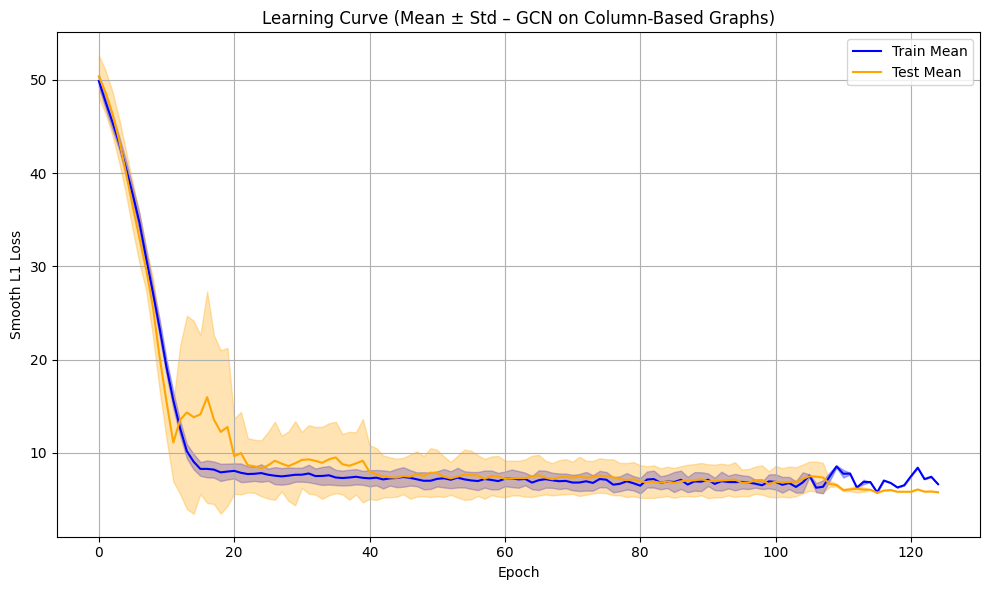

In [ ]:
# Plot mean ± std
plt.figure(figsize=(10, 6))

plt.plot(train_mean, label="Train Mean", color="blue")
plt.fill_between(range(epochs), np.array(train_mean) - np.array(train_std),
                 np.array(train_mean) + np.array(train_std), color="blue", alpha=0.3)

plt.plot(test_mean, label="Test Mean", color="orange")
plt.fill_between(range(epochs), np.array(test_mean) - np.array(test_std),
                 np.array(test_mean) + np.array(test_std), color="orange", alpha=0.3)

plt.xlabel("Epoch")
plt.ylabel("Smooth L1 Loss")
plt.title("Learning Curve (Mean ± Std – GCN on Column-Based Graphs)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## PREDICTION & METRIC ANALYSIS (COLUMN-BASED GRAPHS)

In [ ]:
##################  PREDICTION & METRIC ANALYSIS (COLUMN-BASED GRAPHS)  ##################

from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt

# Ignore future warnings
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# === Initialize storage ===
fold_mae_list = []
fold_r2_list = []
fold_rmse_list = []

all_subject_ids = []
all_y_true = []
all_y_pred = []

# Create a new folder to save the y_true, y_pred, and subject_ids in each fold and repeat
if not os.path.exists("column_md_results"):
    os.makedirs("column_md_results")

for fold, (train_idx, test_idx) in enumerate(skf.split(aligned_graph_list, age_bins)):
    print(f'\n--- Evaluating Fold {fold+1}/{k} ---')

    test_data = [aligned_graph_list[i] for i in test_idx]
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_aligend)
    train_data = [aligned_graph_list[i] for i in train_idx]
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_aligend)

    repeat_maes = []
    repeat_r2s = []
    repeat_rmses = []

    for rep in range(repeats_per_fold):
        print(f"  > Repeat {rep+1}/{repeats_per_fold}")

        model = BrainAgeGNN(input_dim=22).to(device)  # ← Your model

        model.load_state_dict(torch.load(f"column_md_model_fold_{fold+1}_rep_{rep+1}.pt"))  # Load saved model
        model.eval()

        subject_id_repeat = []
        y_true_repeat = []
        y_pred_repeat = []

        subject_id_repeat_train = []
        y_true_repeat_train = []
        y_pred_repeat_train = []

        with torch.no_grad():
            for data in test_loader:
                data = data.to(device)
                output = model(data).view(-1)
                subject_id_repeat.extend(data.subject_id)
                y_pred_repeat.extend(output.cpu().tolist())
                y_true_repeat.extend(data.y.cpu().tolist())
            # Save predictions and true values to files
            test_results_df = pd.DataFrame({
                'subject_id': subject_id_repeat,
                'y_true': y_true_repeat,
                'y_pred': y_pred_repeat
            })
            test_results_df.to_csv(f"column_md_results/fold_{fold+1}_rep_{rep+1}_test_results.csv", index=False)

            for data in train_loader:
                data = data.to(device)
                output = model(data).view(-1)
                subject_id_repeat_train.extend(data.subject_id)
                y_pred_repeat_train.extend(output.cpu().tolist())
                y_true_repeat_train.extend(data.y.cpu().tolist())
            # Save predictions and true values for training data
            train_results_df = pd.DataFrame({
                'subject_id': subject_id_repeat_train,
                'y_true': y_true_repeat_train,
                'y_pred': y_pred_repeat_train
            })
            train_results_df.to_csv(f"column_md_results/fold_{fold+1}_rep_{rep+1}_train_results.csv", index=False)

        # Compute metrics
        mae = mean_absolute_error(y_true_repeat, y_pred_repeat)
        r2 = r2_score(y_true_repeat, y_pred_repeat)
        rmse = np.sqrt(mean_squared_error(y_true_repeat, y_pred_repeat))

        repeat_maes.append(mae)
        repeat_r2s.append(r2)
        repeat_rmses.append(rmse)

        all_y_true.extend(y_true_repeat)
        all_y_pred.extend(y_pred_repeat)
        all_subject_ids.extend(subject_id_repeat)

    fold_mae_list.append(repeat_maes)
    fold_r2_list.append(repeat_r2s)
    fold_rmse_list.append(repeat_rmses)

    print(f">> Fold {fold+1} | MAE: {np.mean(repeat_maes):.2f} ± {np.std(repeat_maes):.2f} | "
          f"R²: {np.mean(repeat_r2s):.2f} ± {np.std(repeat_r2s):.2f} | "
          f"RMSE: {np.mean(repeat_rmses):.2f} ± {np.std(repeat_rmses):.2f}")




--- Evaluating Fold 1/7 ---
  > Repeat 1/10
  > Repeat 2/10
  > Repeat 3/10
  > Repeat 4/10
  > Repeat 5/10
  > Repeat 6/10
  > Repeat 7/10
  > Repeat 8/10
  > Repeat 9/10
  > Repeat 10/10
>> Fold 1 | MAE: 6.01 ± 0.26 | R²: 0.69 ± 0.02 | RMSE: 8.46 ± 0.30

--- Evaluating Fold 2/7 ---
  > Repeat 1/10
  > Repeat 2/10
  > Repeat 3/10
  > Repeat 4/10
  > Repeat 5/10
  > Repeat 6/10
  > Repeat 7/10
  > Repeat 8/10
  > Repeat 9/10
  > Repeat 10/10
>> Fold 2 | MAE: 5.68 ± 0.43 | R²: 0.70 ± 0.04 | RMSE: 7.70 ± 0.49

--- Evaluating Fold 3/7 ---
  > Repeat 1/10
  > Repeat 2/10
  > Repeat 3/10
  > Repeat 4/10
  > Repeat 5/10
  > Repeat 6/10
  > Repeat 7/10
  > Repeat 8/10
  > Repeat 9/10
  > Repeat 10/10
>> Fold 3 | MAE: 4.96 ± 0.26 | R²: 0.77 ± 0.03 | RMSE: 6.08 ± 0.39

--- Evaluating Fold 4/7 ---
  > Repeat 1/10
  > Repeat 2/10
  > Repeat 3/10
  > Repeat 4/10
  > Repeat 5/10
  > Repeat 6/10
  > Repeat 7/10
  > Repeat 8/10
  > Repeat 9/10
  > Repeat 10/10
>> Fold 4 | MAE: 5.94 ± 0.27 | R²: 0.72

In [ ]:
# === Final aggregate results ===
all_maes = np.array(fold_mae_list).flatten()
all_r2s = np.array(fold_r2_list).flatten()
all_rmses = np.array(fold_rmse_list).flatten()

print("\n================== FINAL METRICS (COLUMN-BASED GCN) ==================")
print(f"Global MAE:  {np.mean(all_maes):.2f} ± {np.std(all_maes):.2f}")
print(f"Global R²:   {np.mean(all_r2s):.2f} ± {np.std(all_r2s):.2f}")
print(f"Global RMSE: {np.mean(all_rmses):.2f} ± {np.std(all_rmses):.2f}")
print("=======================================================================")



================== FINAL METRICS (COLUMN-BASED GCN) ==================
Global MAE:  5.71 ± 1.25
Global R²:   0.73 ± 0.10
Global RMSE: 7.42 ± 1.63


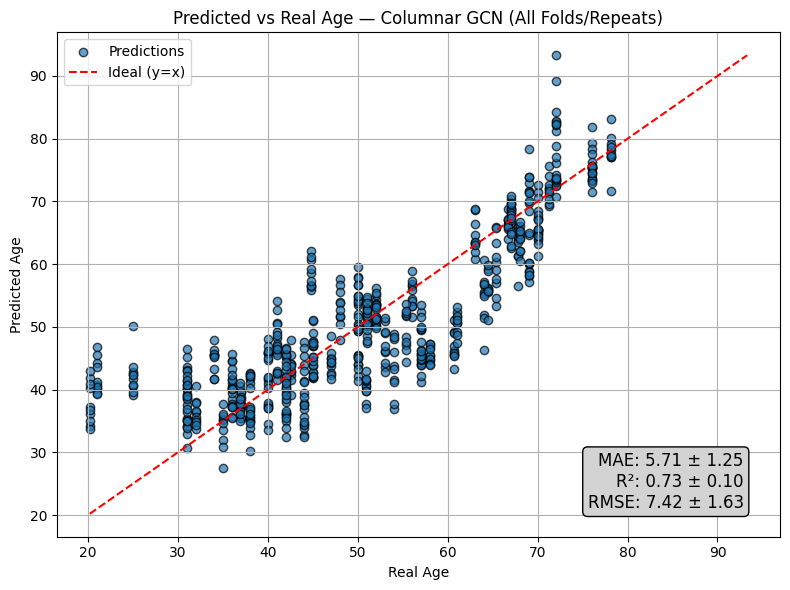

In [ ]:
######################  PLOT TRUE VS PREDICTED AGES (COLUMN-BASED)  ######################

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))

# Scatter plot of true vs predicted ages
plt.scatter(all_y_true, all_y_pred, alpha=0.7, edgecolors='k', label="Predictions")


# Diagonal (ideal prediction)
min_val = min(min(all_y_true), min(all_y_pred))
max_val = max(max(all_y_true), max(all_y_pred))
margin = (max_val - min_val) * 0.05
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="dashed", label="Ideal (y=x)")
plt.xlim(min_val - margin, max_val + margin)
plt.ylim(min_val - margin, max_val + margin)


# Metrics text box with MAE, R² and RMSE
textstr = (f"MAE: {np.mean(all_maes):.2f} ± {np.std(all_maes):.2f}\n"
           f"R²: {np.mean(all_r2s):.2f} ± {np.std(all_r2s):.2f}\n"
           f"RMSE: {np.mean(all_rmses):.2f} ± {np.std(all_rmses):.2f}")

plt.text(0.95, 0.05, textstr, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="lightgray"))

# Labels and style
plt.xlabel("Real Age")
plt.ylabel("Predicted Age")
plt.title("Predicted vs Real Age — Columnar GCN (All Folds/Repeats)")
plt.legend(loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()



In [ ]:
# Save all_y_true and all_y_pred to CSV
import pandas as pd
# Create a DataFrame from the true and predicted values
# For each subject, there're 7 folds and 10 repeats, so we can flatten the lists and match them
# all_y_true = 67 subjects * 10 repeats * 7 folds = 4690 values
# all_y_pred = 67 subjects * 10 repeats * 7 folds = 4690 values
# Flatten subject IDs if they are lists of lists
def flatten(l):
    return [item for sublist in l for item in sublist] if isinstance(l[0], list) else l

flat_subject_ids = flatten(all_subject_ids)

# Print the length of flat_subject_ids
print(f"Total subjects in flattened list: {len(flat_subject_ids)}")

Total subjects in flattened list: 660


In [ ]:
df_results = pd.DataFrame({
    'subject_id': flat_subject_ids,
    'y_true': all_y_true,
    'y_pred': all_y_pred
})
# Save the mean and std of the predicted ages for each subject
df_results_mean_std = df_results.groupby('subject_id').agg(
    y_true_mean=('y_true', 'mean'),
    y_true_std=('y_true', 'std'),
    y_pred_mean=('y_pred', 'mean'),
    y_pred_std=('y_pred', 'std')
).reset_index()
# Save to CSV
df_results_mean_std.to_csv("column_based_gcn_results.csv", index=False)

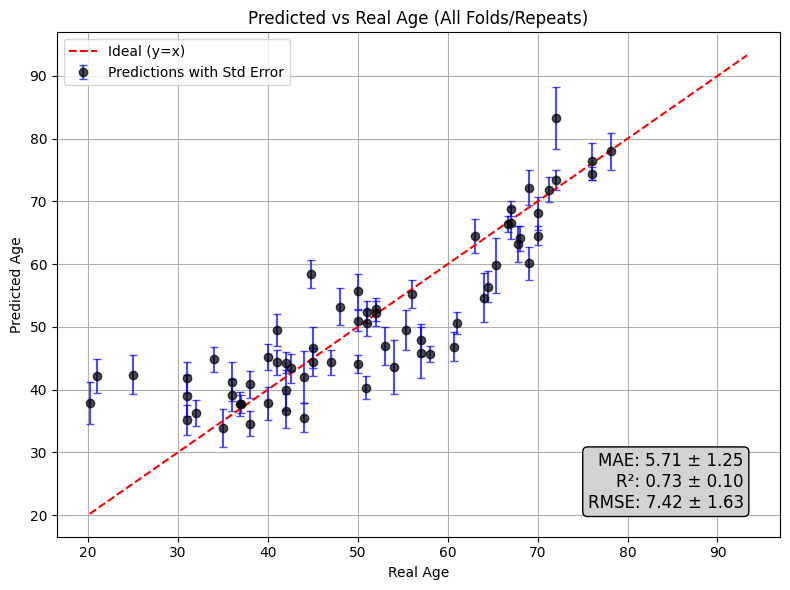

In [ ]:
# Plot y_true vs y_pred with error bar being the std of y_pred for each subject
plt.figure(figsize=(8, 6))
plt.errorbar(df_results_mean_std['y_true_mean'], df_results_mean_std['y_pred_mean'],
             yerr=df_results_mean_std['y_pred_std'], fmt='o', alpha=0.7,
             label='Predictions with Std Error', color='black', ecolor='blue',
                capsize=3)
# Diagonal (ideal prediction)
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="dashed", label="Ideal (y=x)")
# Metrics text box with MAE, R² and RMSE
textstr = (f"MAE: {np.mean(all_maes):.2f} ± {np.std(all_maes):.2f}\n"
           f"R²: {np.mean(all_r2s):.2f} ± {np.std(all_r2s):.2f}\n"
           f"RMSE: {np.mean(all_rmses):.2f} ± {np.std(all_rmses):.2f}")

plt.text(0.95, 0.05, textstr, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="lightgray"))

# Labels and style
plt.xlabel("Real Age")
plt.ylabel("Predicted Age")
plt.title("Predicted vs Real Age (All Folds/Repeats)")
plt.legend(loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#Evaluation done



## Final Model training on healthy+Familial

In [ ]:
############################################

# FINAL MODEL TRAINING ON HEALTHY + FAMILIAL

############################################

print("\n=== Training Final Model on All Healthy + Familial Subjects ===")

from torch_geometric.loader import DataLoader


# === Create DataLoader with all filtered subjects ===
final_train_loader = DataLoader(graph_data_list, batch_size=6, shuffle=True)


# === Initialize model ===
final_model = BrainAgeGNN(input_dim=22).to(device)


# === Optimizer and learning rate scheduler ===
optimizer = torch.optim.AdamW(final_model.parameters(), lr=0.002, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)


# === Loss function ===
criterion = torch.nn.SmoothL1Loss(beta=1)



In [ ]:
# === Train for fixed number of epochs (no early stopping) ===
epochs = 100

for epoch in range(epochs):
    final_model.train()
    total_loss = 0

    for data in final_train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        output = final_model(data).view(-1)
        loss = criterion(output, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(final_train_loader)
    print(f"Epoch {epoch+1:03d} | Loss: {avg_loss:.4f}")

    scheduler.step()



In [ ]:
# === Save final model ===
torch.save(final_model.state_dict(), "column_md_model_trained_on_all_healthy.pt")
print("\nFinal model saved as 'model_trained_on_all_healthy.pt'")



In [ ]:
# === Notes ===

# We selected 100 epochs for the final model training based on the early stopping

# behavior observed during cross-validation. Most runs converged between 60–90 epochs (mean=86)

# so 100 allows for full convergence without early stopping.

